# Yield Prediction — Régression ML
**Module 2 — Système Intelligent d'Aide à la Décision Agricole**

> Objectif : prédire le rendement agricole **(hg/ha)** à partir de la culture, du pays et de l'année.


## Partie 1 — Imports & Configuration

In [1]:
# ── Librairies standard ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import json
import time
warnings.filterwarnings('ignore')

# ── Sklearn ───────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score,
    RandomizedSearchCV
)
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
import joblib

# ── XGBoost ───────────────────────────────────────────────────────────
from xgboost import XGBRegressor

# ── Configuration graphique ───────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = {
    'primary':   '#2D6A4F',
    'secondary': '#52B788',
    'accent':    '#F4A261',
    'danger':    '#E63946',
    'purple':    '#7F77DD',
    'light':     '#D8F3DC',
    'dark':      '#1B4332'
}

# ── Répertoire des artefacts ──────────────────────────────────────────
ARTIFACTS_DIR = '../artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print('Imports réussis')
print(f'Dossier artifacts : {os.path.abspath(ARTIFACTS_DIR)}')


Imports réussis
Dossier artifacts : c:\Users\sofya\Downloads\projet_ML\artifacts


## Partie 2 — Lecture des données

In [3]:
df_raw = pd.read_csv(r'C:\Users\sofya\Downloads\projet_ML\data\yield.csv')
print(f'Shape brut : {df_raw.shape}')
print(f'Colonnes   : {df_raw.columns.tolist()}')
df_raw.head(3)

Shape brut : (56717, 12)
Colonnes   : ['Domain Code', 'Domain', 'Area Code', 'Area', 'Element Code', 'Element', 'Item Code', 'Item', 'Year Code', 'Year', 'Unit', 'Value']


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56717 entries, 0 to 56716
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Domain Code   56717 non-null  object
 1   Domain        56717 non-null  object
 2   Area Code     56717 non-null  int64 
 3   Area          56717 non-null  object
 4   Element Code  56717 non-null  int64 
 5   Element       56717 non-null  object
 6   Item Code     56717 non-null  int64 
 7   Item          56717 non-null  object
 8   Year Code     56717 non-null  int64 
 9   Year          56717 non-null  int64 
 10  Unit          56717 non-null  object
 11  Value         56717 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 5.2+ MB


In [5]:
df_raw.describe()


,Area Code,Element Code,Item Code,Year Code,Year,Value
count,56717.000000,56717.0,56717.000000,56717.000000,56717.000000,56717.000000
mean,125.650422,5419.0,111.611651,1989.669570,1989.669570,62094.660084
std,75.120195,0.0,101.278435,16.133198,16.133198,67835.932856
min,1.000000,5419.0,15.000000,1961.000000,1961.000000,0.000000
25%,58.000000,5419.0,56.000000,1976.000000,1976.000000,15680.000000
50%,122.000000,5419.0,116.000000,1991.000000,1991.000000,36744.000000
75%,184.000000,5419.0,125.000000,2004.000000,2004.000000,86213.000000
max,351.000000,5419.0,489.000000,2016.000000,2016.000000,1000000.000000


### Dictionnaire des colonnes

| Colonne | Représente | Type | Rôle ML |
|---------|-----------|------|---------|
| `Domain Code` | Code FAO du domaine (toujours "QC") | Catégoriel | 1 seule valeur → inutile |
| `Domain` | Nom du domaine (toujours "Crops") | Catégoriel | 1 seule valeur → inutile |
| `Area Code` | **Encodage numérique du pays** (ex: 2=Afghanistan) | Numérique | Label encoding arbitraire → remplacer |
| `Area` | Nom du pays / région (212 pays) | Catégoriel | Feature principale → Target Encoding |
| `Element Code` | Code de la mesure (toujours 5419) | Numérique | 1 seule valeur → inutile |
| `Element` | Type de mesure (toujours "Yield") | Catégoriel | 1 seule valeur → inutile |
| `Item Code` | **Encodage numérique de la culture** (ex: 56=Maize) | Numérique | Label encoding arbitraire → remplacer |
| `Item` | Nom de la culture (10 cultures) | Catégoriel | Feature → One-Hot Encoding |
| `Year Code` | **Identique à Year** (doublon exact) | Numérique | Doublon → supprimer |
| `Year` | Année de la mesure (1961–2016) | Numérique | Feature temporelle |
| `Unit` | Unité (toujours "hg/ha") | Catégoriel | 1 seule valeur → inutile |
| `Value` | Rendement en hg/ha | Numérique | **TARGET** |

> 💡 **Conclusion** : `Area Code` et `Item Code` sont des encodages label arbitraires générés par la FAO. Ils ne conviennent **pas** pour la régression : ils imposent un ordre entre pays/cultures qui n'a aucun sens.  
> `Year Code` est un doublon exact de `Year`.  
> `Domain Code`, `Element Code`, `Unit` n'ont qu'une valeur → aucune information pour le modèle.


## Partie 3 — Nettoyage des Données

In [6]:
# Valeurs manquantes
print("=== Valeurs manquantes ===")
print(df_raw.isnull().sum())

# Doublons
print("=== Doublons ===")
print(f"Nombre de lignes dupliquées : {df_raw.duplicated().sum()}")


=== Valeurs manquantes ===
Domain Code     0
Domain          0
Area Code       0
Area            0
Element Code    0
Element         0
Item Code       0
Item            0
Year Code       0
Year            0
Unit            0
Value           0
dtype: int64
=== Doublons ===
Nombre de lignes dupliquées : 0


In [7]:
# ── Nettoyage ─────────────────────────────────────────────────────────
df = df_raw.copy()

# 1. Filtrer uniquement les lignes 'Yield'
df = df[df['Element'] == 'Yield'].copy()

# 2. Supprimer les doublons
df = df.drop_duplicates()

# 3. Supprimer les valeurs nulles ou égales à zéro (données manquantes déguisées)
df = df[df['Value'] > 0].copy()

# 4. Supprimer les colonnes inutiles
#    Domain Code / Domain   → 1 seule valeur
#    Area Code / Item Code  → labels FAO arbitraires (remplacés par encodage intelligent)
#    Element Code / Element → 1 seule valeur après filtrage
#    Year Code              → doublon exact de Year
#    Unit                   → toujours hg/ha
cols_to_drop = ['Domain Code', 'Domain', 'Area Code', 'Item Code',
                'Element Code', 'Element', 'Year Code', 'Unit']
df = df.drop(columns=cols_to_drop)

df = df.reset_index(drop=True)

print(f'Shape après nettoyage : {df.shape}')
print(f'Cultures disponibles  : {sorted(df["Item"].unique())}')
print(f'Pays disponibles      : {df["Area"].nunique()} pays')
print(f'Années                : {df["Year"].min()} → {df["Year"].max()}')
print(f'Valeurs nulles restantes :\n{df.isnull().sum()}')
print("Colonnes conservées   :", df.columns.tolist())
print()
df.head()

Shape après nettoyage : (56709, 4)
Cultures disponibles  : ['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']
Pays disponibles      : 212 pays
Années                : 1961 → 2016
Valeurs nulles restantes :
Area     0
Item     0
Year     0
Value    0
dtype: int64
Colonnes conservées   : ['Area', 'Item', 'Year', 'Value']



,Area,Item,Year,Value
0,Afghanistan,Maize,1961,14000
1,Afghanistan,Maize,1962,14000
2,Afghanistan,Maize,1963,14260
3,Afghanistan,Maize,1964,14257
4,Afghanistan,Maize,1965,14400


## Partie 4 — Outliers

In [8]:
# Outliers — méthode IQR (sur colonnes numériques utiles)
numeric_df = df.select_dtypes(include=['number'])
Q1  = numeric_df.quantile(0.25)
Q3  = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers_mask = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))

print("=== Nombre d'outliers par colonne numérique ===")
print(outliers_mask.sum())
print()
nb_out = outliers_mask['Value'].sum()
pct    = nb_out / len(df) * 100
print(f"Outliers dans Value : {nb_out} lignes ({pct:.1f}% du dataset)")
print(f"Skewness de Value   : {df['Value'].skew():.3f}  (> 1 = forte asymétrie à droite)")
print()
print("→ Ces outliers sont des RENDEMENTS RÉELS (ex: Potatoes aux Pays-Bas = 400 000+ hg/ha)")
print("→ Stratégie : transformation log1p sur la cible, pas de suppression")


=== Nombre d'outliers par colonne numérique ===
Year        0
Value    3168
dtype: int64

Outliers dans Value : 3168 lignes (5.6% du dataset)
Skewness de Value   : 2.205  (> 1 = forte asymétrie à droite)

→ Ces outliers sont des RENDEMENTS RÉELS (ex: Potatoes aux Pays-Bas = 400 000+ hg/ha)
→ Stratégie : transformation log1p sur la cible, pas de suppression


## Partie 5 — Visualisation des outliers

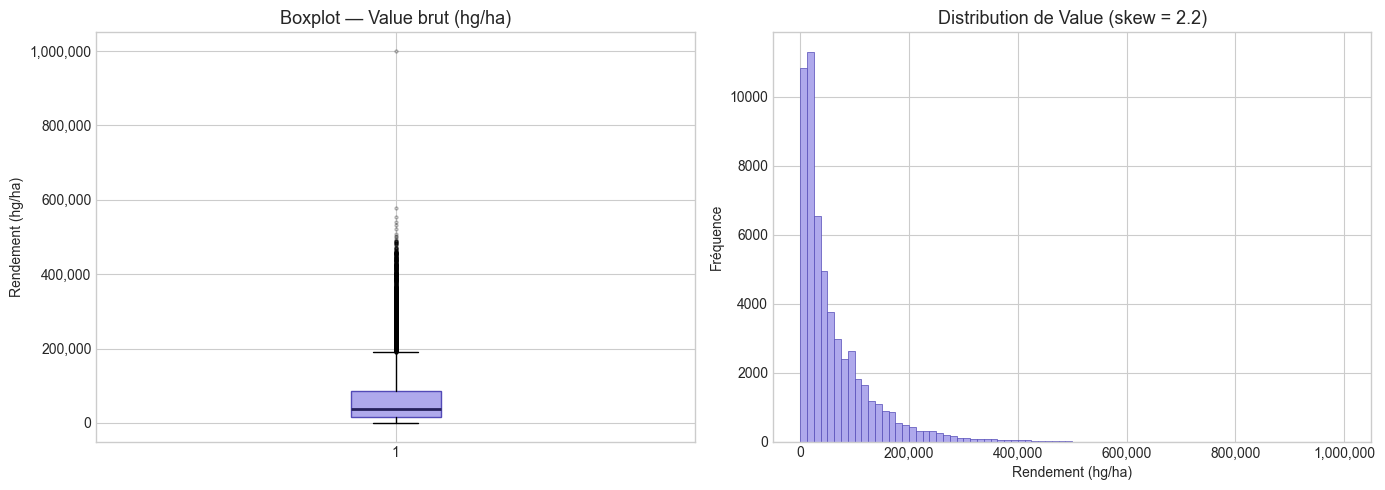

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(df['Value'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#AFA9EC', color='#534AB7'),
                medianprops=dict(color='#26215C', linewidth=2),
                flierprops=dict(marker='o', markersize=2, alpha=0.3, color='#D85A30'))
axes[0].set_title('Boxplot — Value brut (hg/ha)', fontsize=13)
axes[0].set_ylabel('Rendement (hg/ha)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Histogramme
axes[1].hist(df['Value'], bins=80, color='#AFA9EC', edgecolor='#534AB7', linewidth=0.5)
axes[1].set_title('Distribution de Value (skew = 2.2)', fontsize=13)
axes[1].set_xlabel('Rendement (hg/ha)')
axes[1].set_ylabel('Fréquence')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()


## Partie 6 — Gestion des outliers : transformation log1p

**Pourquoi pas IQR capping ?**  
Ces outliers sont des données réelles (rendements records de certains pays). Les supprimer ou les plafonner biaiserait le modèle géographiquement — il sous-estimerait systématiquement les pays très productifs.

**Solution : `np.log1p(Value)`**  
- Compresse la queue droite sans perdre aucune donnée
- Symétrize la distribution → les modèles RF et XGBoost convergent mieux
- Après prédiction, on inverse avec `np.expm1()` pour retrouver les hg/ha réels


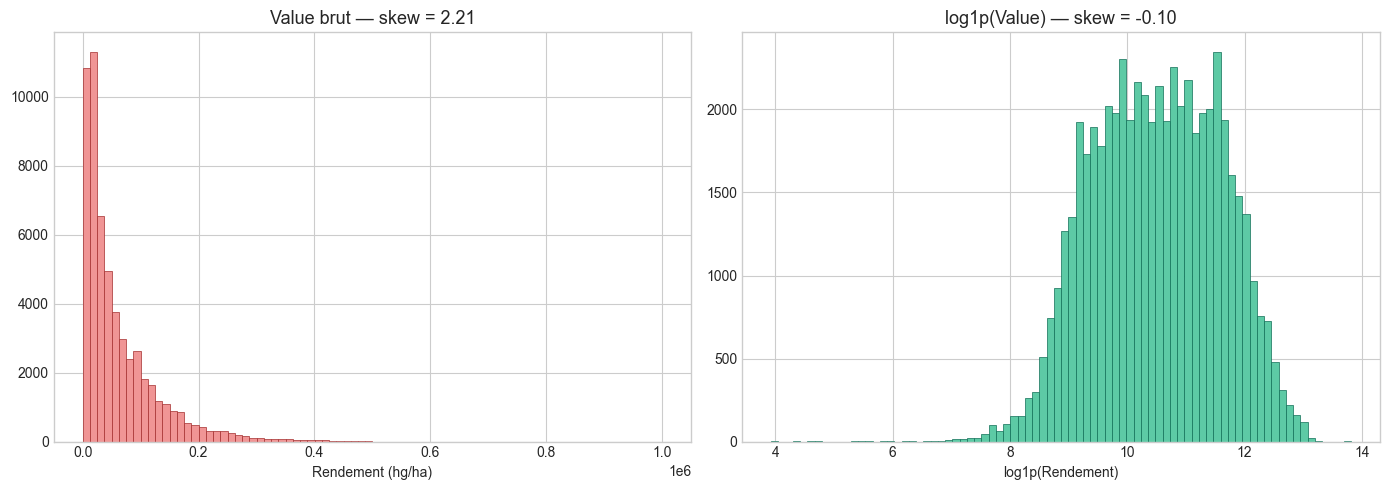

→ La distribution est maintenant bien plus symétrique


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Value'], bins=80, color='#F09595', edgecolor='#A32D2D', linewidth=0.5)
axes[0].set_title(f'Value brut — skew = {df["Value"].skew():.2f}', fontsize=13)
axes[0].set_xlabel('Rendement (hg/ha)')

log_vals = np.log1p(df['Value'])
axes[1].hist(log_vals, bins=80, color='#5DCAA5', edgecolor='#0F6E56', linewidth=0.5)
axes[1].set_title(f'log1p(Value) — skew = {log_vals.skew():.2f}', fontsize=13)
axes[1].set_xlabel('log1p(Rendement)')

plt.tight_layout()
plt.show()
print("→ La distribution est maintenant bien plus symétrique")


## Partie 7 — Analyse Exploratoire (EDA)

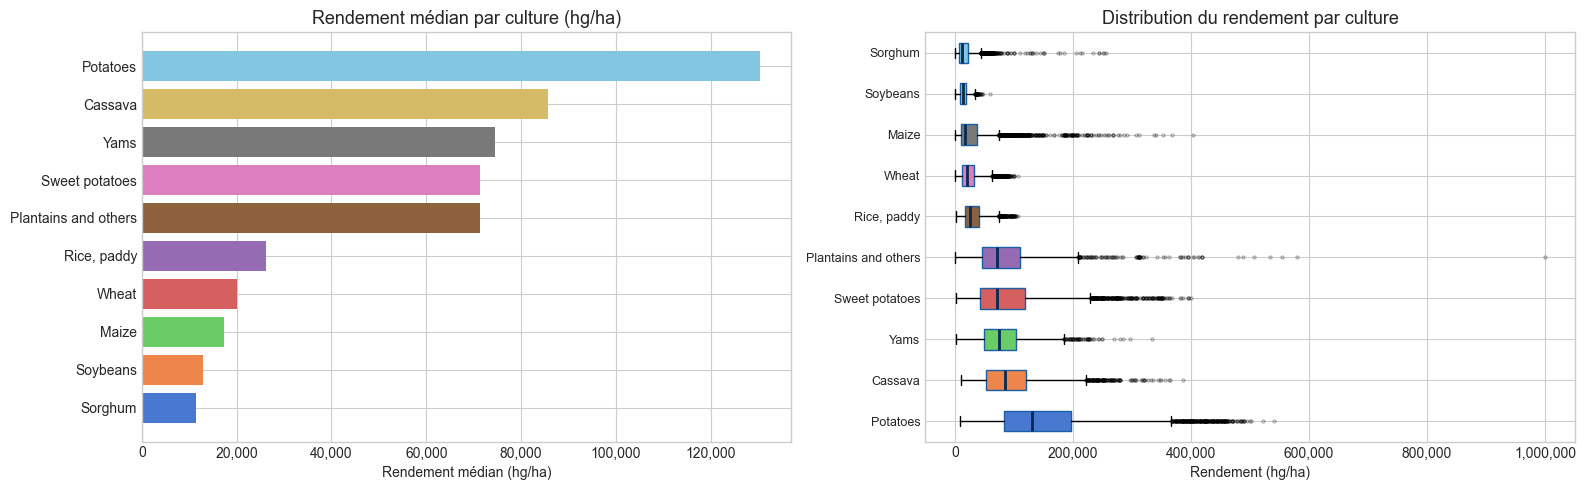

→ Potatoes a le rendement le plus élevé mais aussi la plus grande variance
→ Cassava, Yams et Sorghum ont les rendements les plus faibles


In [11]:
# Rendement médian par culture + boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order = df.groupby('Item')['Value'].median().sort_values(ascending=False).index.tolist()
colors = sns.color_palette("muted", len(order))

crop_medians = df.groupby('Item')['Value'].median().loc[order]
axes[0].barh(order[::-1], crop_medians[order[::-1]].values, color=colors)
axes[0].set_title('Rendement médian par culture (hg/ha)', fontsize=13)
axes[0].set_xlabel('Rendement médian (hg/ha)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

data_ordered = [df[df['Item'] == c]['Value'].values for c in order]
bp = axes[1].boxplot(data_ordered, vert=False, patch_artist=True,
                     boxprops=dict(color='#185FA5'),
                     medianprops=dict(color='#042C53', linewidth=2),
                     flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], sns.color_palette("muted", len(order))):
    patch.set_facecolor(color)
axes[1].set_yticks(range(1, len(order)+1))
axes[1].set_yticklabels(order, fontsize=9)
axes[1].set_title('Distribution du rendement par culture', fontsize=13)
axes[1].set_xlabel('Rendement (hg/ha)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()
print("→ Potatoes a le rendement le plus élevé mais aussi la plus grande variance")
print("→ Cassava, Yams et Sorghum ont les rendements les plus faibles")


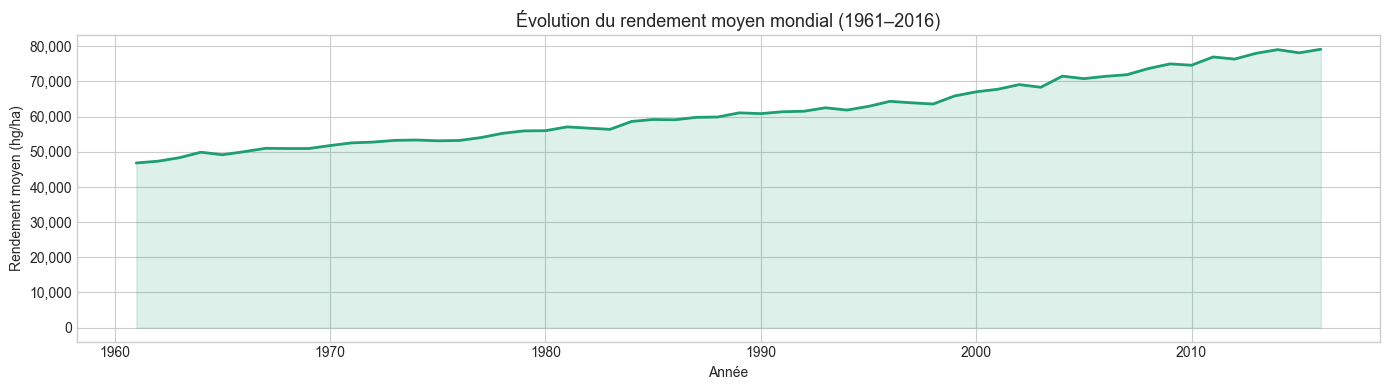

→ Tendance linéaire croissante : l'année est un prédicteur temporel fort


In [12]:
# Évolution temporelle globale
year_means = df.groupby('Year')['Value'].mean()

plt.figure(figsize=(14, 4))
plt.plot(year_means.index, year_means.values, color='#1D9E75', linewidth=2)
plt.fill_between(year_means.index, year_means.values, alpha=0.15, color='#1D9E75')
plt.title('Évolution du rendement moyen mondial (1961–2016)', fontsize=13)
plt.xlabel('Année')
plt.ylabel('Rendement moyen (hg/ha)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()
print("→ Tendance linéaire croissante : l'année est un prédicteur temporel fort")


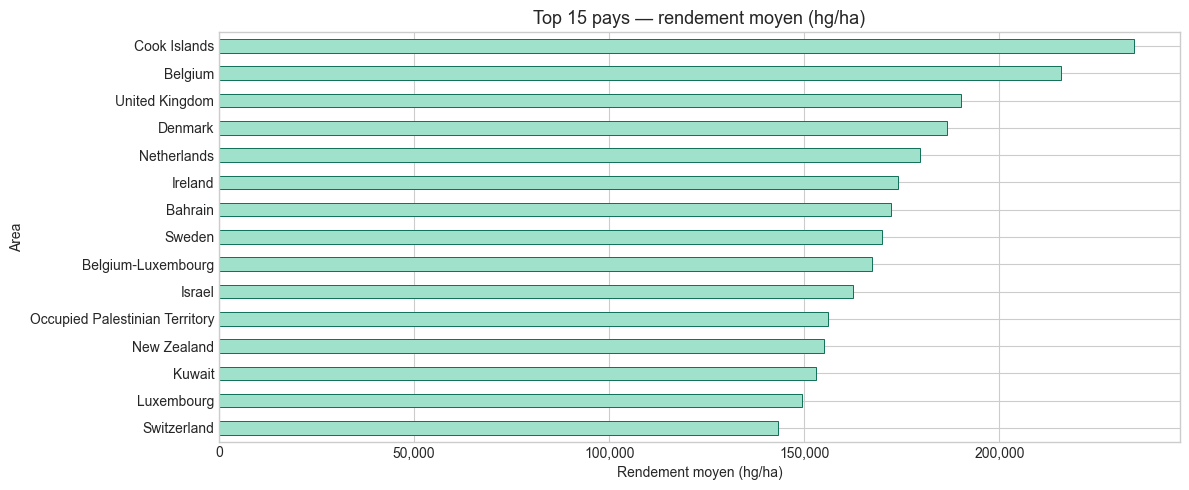

→ Énorme variabilité inter-pays → Area est un prédicteur géographique critique


In [13]:
# Top 15 pays — rendement moyen
top_areas = df.groupby('Area')['Value'].mean().nlargest(15).sort_values()

plt.figure(figsize=(12, 5))
top_areas.plot(kind='barh', color='#9FE1CB', edgecolor='#0F6E56', linewidth=0.7)
plt.title('Top 15 pays — rendement moyen (hg/ha)', fontsize=13)
plt.xlabel('Rendement moyen (hg/ha)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()
print("→ Énorme variabilité inter-pays → Area est un prédicteur géographique critique")


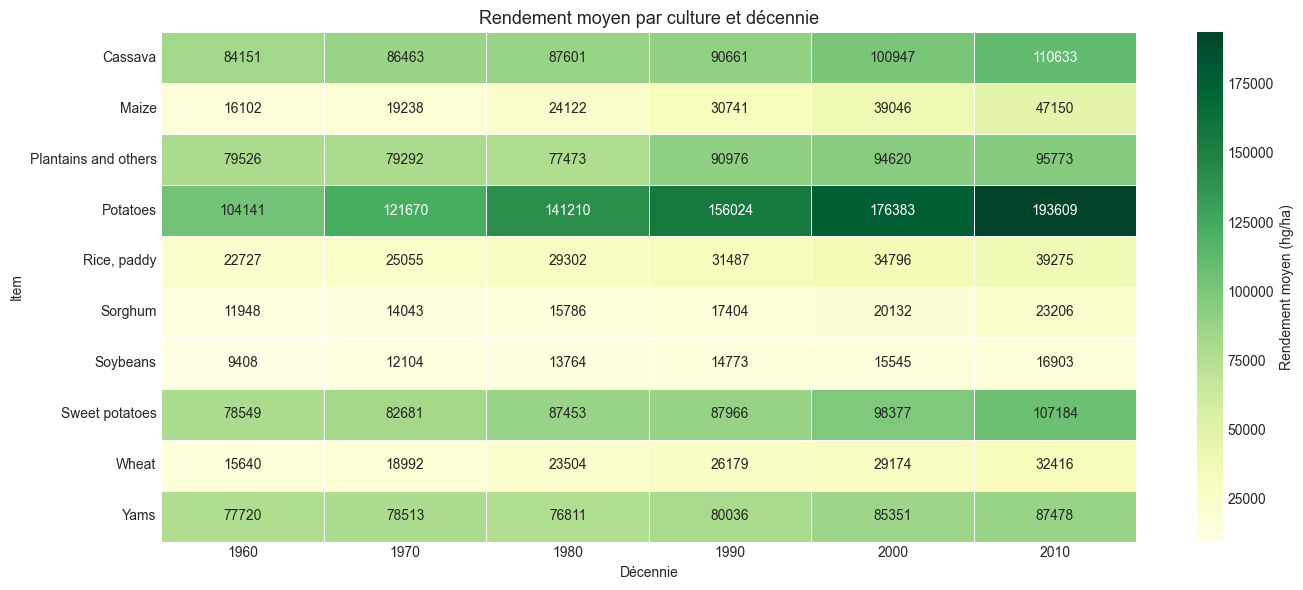

→ On voit clairement la progression technologique agricole au fil des décennies


In [14]:
# Heatmap rendement moyen par culture × décennie
df['Decade'] = (df['Year'] // 10) * 10
pivot = df.pivot_table(values='Value', index='Item', columns='Decade', aggfunc='mean')

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGn',
            linewidths=0.5, cbar_kws={'label': 'Rendement moyen (hg/ha)'})
plt.title('Rendement moyen par culture et décennie', fontsize=13)
plt.xlabel('Décennie')
plt.tight_layout()
plt.show()
print("→ On voit clairement la progression technologique agricole au fil des décennies")


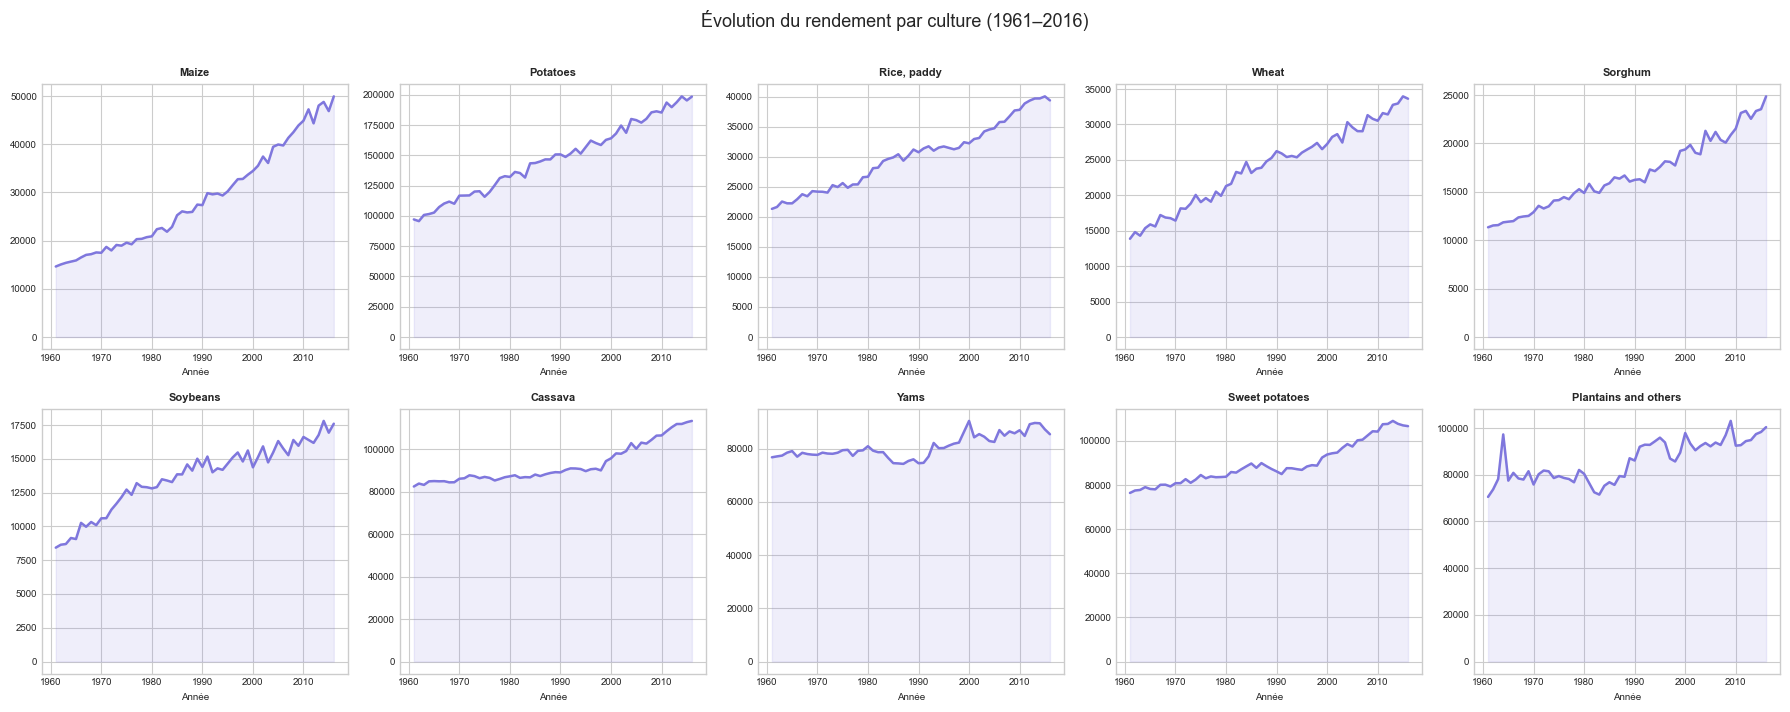

In [15]:
# Évolution par culture
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)
axes = axes.flatten()
items = df['Item'].unique()

for i, item in enumerate(items):
    sub = df[df['Item'] == item]
    yearly = sub.groupby('Year')['Value'].mean()
    axes[i].plot(yearly.index, yearly.values, color='#7F77DD', linewidth=1.8)
    axes[i].fill_between(yearly.index, yearly.values, alpha=0.12, color='#7F77DD')
    axes[i].set_title(item, fontsize=8, fontweight='bold')
    axes[i].set_xlabel('Année', fontsize=7)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Évolution du rendement par culture (1961–2016)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [16]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# ─────────────────────────────────────────────────────────────────────
# NOTE : Le Target Encoding de Area est volontairement déplacé APRÈS
# le train/test split (Partie 8) pour éviter tout data leakage.
# Ici on prépare uniquement les colonnes OHE + Year.
# ─────────────────────────────────────────────────────────────────────

df_model = df.copy()

print("✓ df_model copié — Target Encoding sera appliqué après le split (Partie 8)")
print(f"  Colonnes disponibles : {df_model.columns.tolist()}")
print(f"  Shape : {df_model.shape}")


✓ df_model copié — Target Encoding sera appliqué après le split (Partie 8)
  Colonnes disponibles : ['Area', 'Item', 'Year', 'Value', 'Decade']
  Shape : (56709, 5)


In [17]:
# ── One-Hot Encoding de Item ─────────────────────────────────────────
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
item_encoded = ohe.fit_transform(df_model[["Item"]])
item_df = pd.DataFrame(item_encoded,
                       columns=ohe.get_feature_names_out(["Item"]),
                       index=df_model.index)

df_model = pd.concat([df_model, item_df], axis=1)
df_model = df_model.drop(columns=["Item"])

print("✓ One-Hot Encoding de Item")
print("  Colonnes créées :", list(ohe.get_feature_names_out(["Item"])))
print()
print("→ Item Code (label FAO) déjà supprimé en Partie 3 : entiers arbitraires non ordinaux")


✓ One-Hot Encoding de Item
  Colonnes créées : ['Item_Cassava', 'Item_Maize', 'Item_Plantains and others', 'Item_Potatoes', 'Item_Rice, paddy', 'Item_Sorghum', 'Item_Soybeans', 'Item_Sweet potatoes', 'Item_Wheat', 'Item_Yams']

→ Item Code (label FAO) déjà supprimé en Partie 3 : entiers arbitraires non ordinaux


In [18]:
# ── Normalisation de Year ─────────────────────────────────────────────
df_model["Year_norm"] = df_model["Year"] - df_model["Year"].min()
df_model = df_model.drop(columns=["Year", "Decade"])

# ── log1p sur la cible ────────────────────────────────────────────────
df_model["log_Value"] = np.log1p(df_model["Value"])

print("✓ Year normalisé → Year_norm (0 à 55)")
print("✓ log1p appliqué sur Value → log_Value")
print()
print("Shape finale du dataset modèle :", df_model.shape)
print("Colonnes :", df_model.columns.tolist())
print()
print(" La colonne 'Area' (texte) est conservée pour le Target Encoding post-split (Partie 8)")
df_model.head(3)


✓ Year normalisé → Year_norm (0 à 55)
✓ log1p appliqué sur Value → log_Value

Shape finale du dataset modèle : (56709, 14)
Colonnes : ['Area', 'Value', 'Item_Cassava', 'Item_Maize', 'Item_Plantains and others', 'Item_Potatoes', 'Item_Rice, paddy', 'Item_Sorghum', 'Item_Soybeans', 'Item_Sweet potatoes', 'Item_Wheat', 'Item_Yams', 'Year_norm', 'log_Value']

 La colonne 'Area' (texte) est conservée pour le Target Encoding post-split (Partie 8)


,Area,Value,Item_Cassava,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams,Year_norm,log_Value
0,Afghanistan,14000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,9.546884
1,Afghanistan,14000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,9.546884
2,Afghanistan,14260,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,9.565284


## Partie 8 — Split train/test + Target Encoding + Mise à l'échelle

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# ── Colonnes features (sans Area texte — on l'encodera après le split) ──
item_cols    = [c for c in df_model.columns if c.startswith("Item_")]
feature_cols = ["Year_norm"] + item_cols   # Area_encoded sera ajouté après

X_raw = df_model[["Area"] + ["Year_norm"] + item_cols]   # Area encore en texte
y     = df_model["log_Value"]   # cible log-transformée

# ── Split AVANT tout encodage ────────────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# ─────────────────────────────────────────────────────────────────────────
# CORRECTION 1 — Target Encoding de Area : calculé UNIQUEMENT sur X_train
# → pas de fuite d'information du test vers le train
# ─────────────────────────────────────────────────────────────────────────
area_means = (X_train_raw["Area"]
              .to_frame()
              .join(y_train)
              .groupby("Area")["log_Value"]
              .mean())

# Appliquer sur train
X_train_enc = X_train_raw.copy()
X_train_enc["Area_encoded"] = X_train_raw["Area"].map(area_means)

# Appliquer sur test (pays inconnus → moyenne globale du train)
X_test_enc = X_test_raw.copy()
X_test_enc["Area_encoded"] = X_test_raw["Area"].map(area_means)
X_test_enc["Area_encoded"].fillna(y_train.mean(), inplace=True)

# Fallback pour train (très rare)
X_train_enc["Area_encoded"].fillna(y_train.mean(), inplace=True)

# Supprimer la colonne texte Area
X_train_enc = X_train_enc.drop(columns=["Area"])
X_test_enc  = X_test_enc.drop(columns=["Area"])

# Mettre à jour feature_cols avec Area_encoded
feature_cols = ["Area_encoded", "Year_norm"] + item_cols

# Réordonner les colonnes
X_train_enc = X_train_enc[feature_cols]
X_test_enc  = X_test_enc[feature_cols]

# ── RobustScaler : fit sur train uniquement ──────────────────────────────
scaler    = RobustScaler()
X_train_s = scaler.fit_transform(X_train_enc)
X_test_s  = scaler.transform(X_test_enc)      # transform seulement sur test !

print(f"Train : {X_train_s.shape}")
print(f"Test  : {X_test_s.shape}")
print(f"Features utilisées : {feature_cols}")
print()
print("✅ Pipeline sans data leakage :")
print("   1. Split train/test")
print("   2. Target Encoding calculé sur train → appliqué sur test via map()")
print("   3. RobustScaler fitté sur train → transformé sur test")


Train : (45367, 12)
Test  : (11342, 12)
Features utilisées : ['Area_encoded', 'Year_norm', 'Item_Cassava', 'Item_Maize', 'Item_Plantains and others', 'Item_Potatoes', 'Item_Rice, paddy', 'Item_Sorghum', 'Item_Soybeans', 'Item_Sweet potatoes', 'Item_Wheat', 'Item_Yams']

✅ Pipeline sans data leakage :
   1. Split train/test
   2. Target Encoding calculé sur train → appliqué sur test via map()
   3. RobustScaler fitté sur train → transformé sur test


## Partie 9 — Entraînement et comparaison des modèles

### Métriques d'évaluation

| Métrique | Interprétation |
|----------|---------------|
| **R²** | Part de variance expliquée. 1 = parfait, 0 = nul |
| **MAE** | Erreur absolue moyenne (espace log) |
| **RMSE** | Penalise davantage les grandes erreurs |
| **MAPE (%)** | % d'erreur moyen en hg/ha réels — la plus interprétable |


In [20]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def evaluate(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    y_real  = np.expm1(y_true)
    yp_real = np.expm1(y_pred)
    mape    = np.mean(np.abs((y_real - yp_real) / (y_real + 1))) * 100
    print(f"{'─'*48}")
    print(f"  {name}")
    print(f"  R²         = {r2:.4f}")
    print(f"  MAE        = {mae:.4f}  (espace log)")
    print(f"  RMSE       = {rmse:.4f}  (espace log)")
    print(f"  MAPE       = {mape:.2f}%  (hg/ha réels)")
    return {"Modèle": name, "R²": round(r2,4), "MAE": round(mae,4),
            "RMSE": round(rmse,4), "MAPE (%)": round(mape,2)}

results = []
predictions = {}


In [21]:
# ── Ridge Regression — baseline linéaire ─────────────────────────────
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
pred_ridge = ridge.predict(X_test_s)
results.append(evaluate("Ridge Regression", y_test, pred_ridge))
predictions["Ridge Regression"] = pred_ridge


────────────────────────────────────────────────
  Ridge Regression
  R²         = 0.7102
  MAE        = 0.4462  (espace log)
  RMSE       = 0.5821  (espace log)
  MAPE       = 57.16%  (hg/ha réels)


In [22]:
# ── Random Forest Regressor ──────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
pred_rf = rf.predict(X_test_s)
results.append(evaluate("Random Forest", y_test, pred_rf))
predictions["Random Forest"] = pred_rf


────────────────────────────────────────────────
  Random Forest
  R²         = 0.9704
  MAE        = 0.1082  (espace log)
  RMSE       = 0.1860  (espace log)
  MAPE       = 11.31%  (hg/ha réels)


In [23]:
# ── XGBoost Regressor ────────────────────────────────────────────────
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                   subsample=0.8, colsample_bytree=0.8,
                   random_state=42, verbosity=0)
xgb.fit(X_train_s, y_train)
pred_xgb = xgb.predict(X_test_s)
results.append(evaluate("XGBoost", y_test, pred_xgb))
predictions["XGBoost"] = pred_xgb


────────────────────────────────────────────────
  XGBoost
  R²         = 0.8518
  MAE        = 0.3134  (espace log)
  RMSE       = 0.4163  (espace log)
  MAPE       = 36.29%  (hg/ha réels)


In [24]:
# ── Gradient Boosting (sklearn) ──────────────────────────────────────
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                max_depth=5, random_state=42)
gb.fit(X_train_s, y_train)
pred_gb = gb.predict(X_test_s)
results.append(evaluate("Gradient Boosting", y_test, pred_gb))
predictions["Gradient Boosting"] = pred_gb


────────────────────────────────────────────────
  Gradient Boosting
  R²         = 0.8545
  MAE        = 0.3113  (espace log)
  RMSE       = 0.4125  (espace log)
  MAPE       = 35.17%  (hg/ha réels)


## Partie 10 — Comparaison des modèles

In [25]:
results_df = pd.DataFrame(results).set_index("Modèle").sort_values("R²", ascending=False)
print("=== Tableau récapitulatif ===")
print(results_df.to_string())
print()
best_r2   = results_df['R²'].idxmax()
best_mape = results_df['MAPE (%)'].idxmin()
print(f" Meilleur R²   : {best_r2}  ({results_df.loc[best_r2,'R²']})")
print(f" Meilleur MAPE : {best_mape}  ({results_df.loc[best_mape,'MAPE (%)']}%)")


=== Tableau récapitulatif ===
                       R²     MAE    RMSE  MAPE (%)
Modèle                                             
Random Forest      0.9704  0.1082  0.1860     11.31
Gradient Boosting  0.8545  0.3113  0.4125     35.17
XGBoost            0.8518  0.3134  0.4163     36.29
Ridge Regression   0.7102  0.4462  0.5821     57.16

 Meilleur R²   : Random Forest  (0.9704)
 Meilleur MAPE : Random Forest  (11.31%)


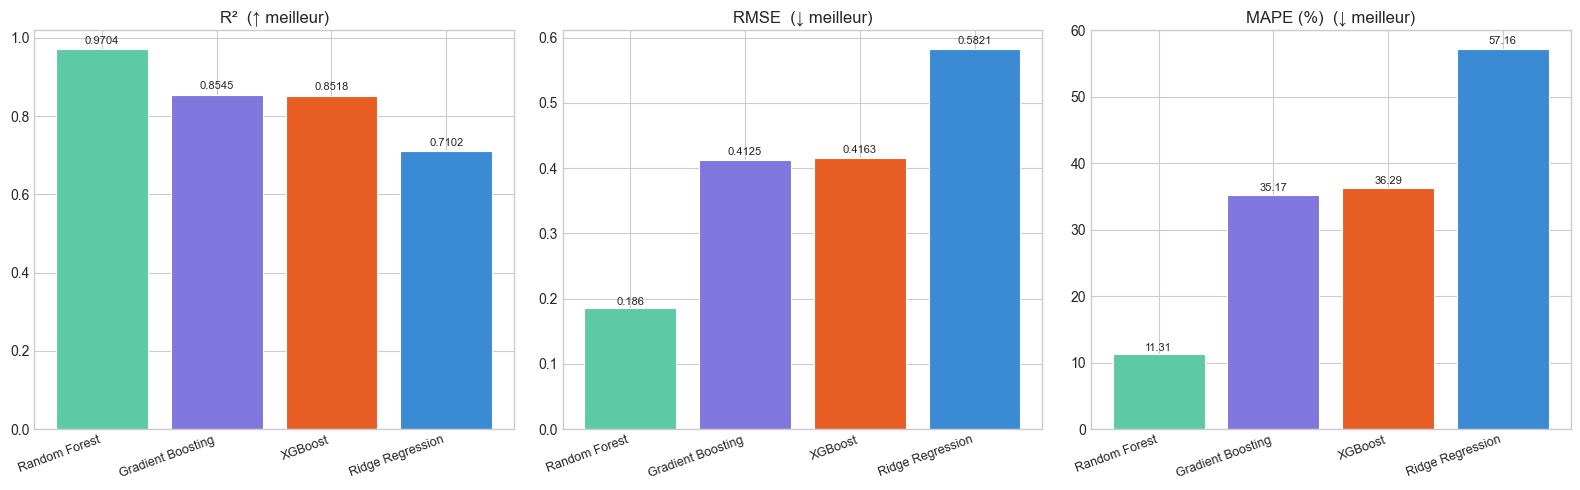

In [26]:
# Graphique comparatif des métriques
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_colors = ['#5DCAA5', '#7F77DD', '#E85D24', '#3B8BD4']
metrics_info = [('R²', '↑ meilleur'), ('RMSE', '↓ meilleur'), ('MAPE (%)', '↓ meilleur')]

for ax, (metric, direction) in zip(axes, metrics_info):
    bars = ax.bar(results_df.index, results_df[metric],
                  color=model_colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f'{metric}  ({direction})', fontsize=12)
    ax.set_xticklabels(results_df.index, rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01, f'{val}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


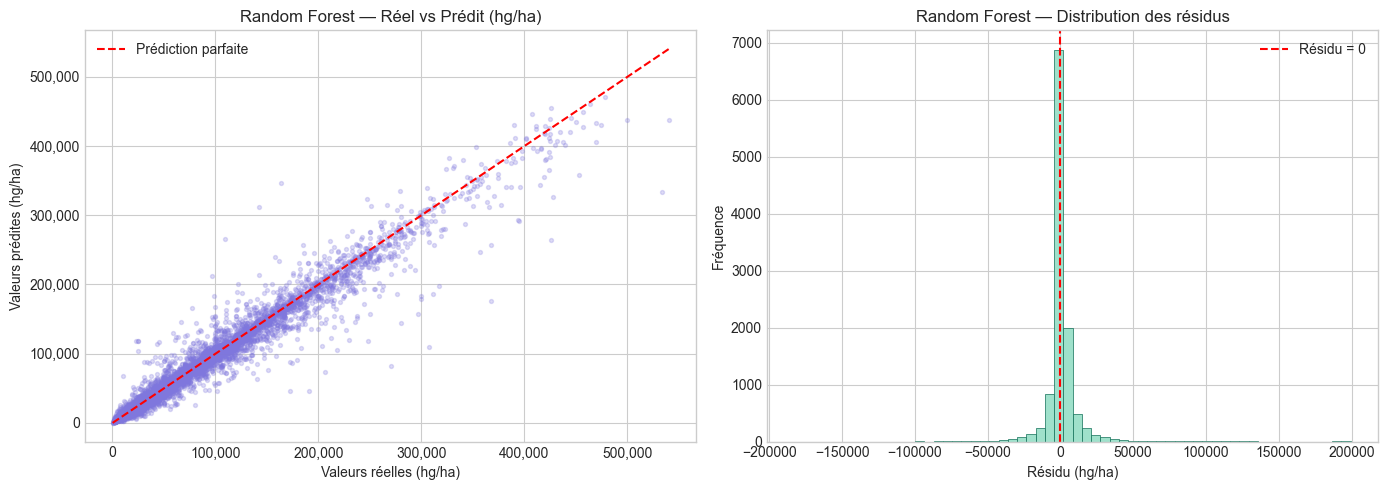

In [27]:
# Scatter réel vs prédit — meilleur modèle
best_name = results_df['R²'].idxmax()
best_pred = predictions[best_name]

y_real  = np.expm1(y_test)
yp_real = np.expm1(best_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_real, yp_real, alpha=0.25, s=8, color='#7F77DD')
mn, mx = y_real.min(), y_real.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Prédiction parfaite')
axes[0].set_title(f'{best_name} — Réel vs Prédit (hg/ha)', fontsize=12)
axes[0].set_xlabel('Valeurs réelles (hg/ha)')
axes[0].set_ylabel('Valeurs prédites (hg/ha)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

residuals = y_real - yp_real
axes[1].hist(residuals, bins=60, color='#9FE1CB', edgecolor='#0F6E56', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Résidu = 0')
axes[1].set_title(f'{best_name} — Distribution des résidus', fontsize=12)
axes[1].set_xlabel('Résidu (hg/ha)')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## Partie 11 — Optimisation des Hyperparamètres (RandomizedSearchCV)

> **Random Forest** a été retenu comme meilleur modèle suite à la comparaison (R² = 0.9704, MAPE = 11.31%).  
> On utilise **RandomizedSearchCV** pour explorer un large espace de paramètres efficacement.

| Paramètre | Rôle |
|-----------|------|
| `n_estimators` | Nombre d'arbres — plus = plus stable |
| `max_depth` | Profondeur max — contrôle la complexité |
| `min_samples_split` | Minimum d'observations pour scinder un nœud |
| `min_samples_leaf` | Minimum d'observations dans une feuille |
| `max_features` | Nombre de features testées à chaque split |
| `bootstrap` | Tirage avec ou sans remise |


In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import time

# ── Espace des hyperparamètres ───────────────────────────────
param_dist = {
    "n_estimators":      randint(100, 600),
    "max_depth":         [None, 10, 20, 30, 40],
    "min_samples_split": randint(2, 15),
    "min_samples_leaf":  randint(1, 8),
    "max_features":      ["sqrt", "log2", 0.5, 0.8],
    "bootstrap":         [True, False]
}

# ── Modèle de base ───────────────────────────────────────────
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# ── Randomized Search ────────────────────────────────────────
search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("⏳ Démarrage de RandomizedSearchCV (Random Forest)...")

t0 = time.time()
search.fit(X_train_s, y_train)
elapsed = time.time() - t0

print(f"\n Recherche terminée en {elapsed:.1f}s")
print("\n Meilleurs hyperparamètres :")
for k, v in search.best_params_.items():
    print(f"   {k:20s} = {v}")
print(f"\n Meilleur R² CV : {search.best_score_:.4f}")

best_params = search.best_params_


⏳ Démarrage de RandomizedSearchCV (Random Forest)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

 Recherche terminée en 564.1s

 Meilleurs hyperparamètres :
   bootstrap            = False
   max_depth            = 40
   max_features         = 0.8
   min_samples_leaf     = 4
   min_samples_split    = 6
   n_estimators         = 506

 Meilleur R² CV : 0.9461


In [30]:
from sklearn.ensemble import RandomForestRegressor

# ── Ré-entraîner avec les meilleurs paramètres ───────────────────────────
# CORRECTION 2 — Modèle nommé 'best_model' pour cohérence dans toutes les parties
best_model = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train_s, y_train)

# ── Prédictions ──────────────────────────────────────────────────────────
pred_train_best = best_model.predict(X_train_s)
pred_test_best  = best_model.predict(X_test_s)

print("✅ Random Forest optimisé entraîné (best_model)")
print(f"   Paramètres : {best_params}")


✅ Random Forest optimisé entraîné (best_model)
   Paramètres : {'bootstrap': False, 'max_depth': 40, 'max_features': 0.8, 'min_samples_leaf': 4, 'min_samples_split': 6, 'n_estimators': 506}


## Partie 12 — Évaluation Finale : R², MAE, RMSE, MAPE

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE en hg/ha réels
    y_real  = np.expm1(y_true)
    yp_real = np.expm1(y_pred)
    mape    = np.mean(np.abs((y_real - yp_real) / (y_real + 1e-8))) * 100

    print(f"\n {'─'*45}")
    print(f"  {name}")
    print(f"  R²         = {r2:.4f}")
    print(f"  MAE        = {mae:.4f}  (espace log)")
    print(f"  RMSE       = {rmse:.4f}  (espace log)")
    print(f"  MAPE       = {mape:.2f}%  (hg/ha réels)")

    return {"R²": r2, "MAE": mae, "RMSE": rmse, "MAPE (%)": round(mape, 2)}


In [32]:
train_metrics = evaluate_model(
    'Random Forest Optimisé — TRAIN',
    y_train,
    pred_train_best
)

test_metrics = evaluate_model(
    'Random Forest Optimisé — TEST',
    y_test,
    pred_test_best
)



 ─────────────────────────────────────────────
  Random Forest Optimisé — TRAIN
  R²         = 0.9806
  MAE        = 0.0971  (espace log)
  RMSE       = 0.1516  (espace log)
  MAPE       = 10.07%  (hg/ha réels)

 ─────────────────────────────────────────────
  Random Forest Optimisé — TEST
  R²         = 0.9554
  MAE        = 0.1511  (espace log)
  RMSE       = 0.2284  (espace log)
  MAPE       = 16.20%  (hg/ha réels)


## Partie 13 — Vérification de l'Overfitting (Train vs Test)

> Comparaison des métriques sur le jeu d'entraînement et le jeu de test.  
> Un bon modèle présente un **gap R² < 0.05** entre Train et Test.


 Cross-Validation 5-Fold sur le modèle final...
   CV R² scores : [0.9492 0.9408 0.9478 0.9477 0.9451]
   CV R² moyen  : 0.9461 ± 0.0030

   Gap Train-Test : 0.0252

 Analyse Overfitting :
  Modèle STABLE → pas d'overfitting détecté


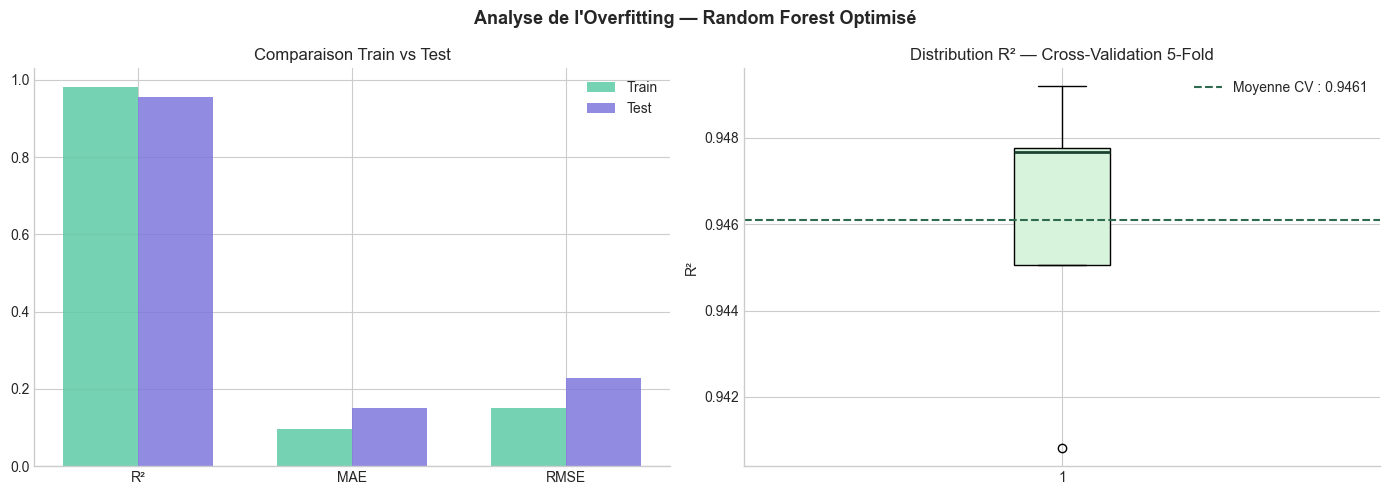

In [33]:
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# ── Cross-Validation 5-Fold ───────────────────────────────────────────
print(' Cross-Validation 5-Fold sur le modèle final...')

cv_scores = cross_val_score(
    best_model,
    X_train_s,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print(f'   CV R² scores : {cv_scores.round(4)}')
print(f'   CV R² moyen  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# ── Détection Overfitting ─────────────────────────────────────────────
gap = train_metrics["R²"] - test_metrics["R²"]
print(f'\n   Gap Train-Test : {gap:.4f}')
print("\n Analyse Overfitting :")

if gap < 0.05 and cv_scores.std() < 0.02:
    print("  Modèle STABLE → pas d'overfitting détecté")
elif gap < 0.10:
    print("  Léger overfitting → acceptable mais à surveiller")
else:
    print("  Overfitting détecté → modèle trop ajusté aux données d'entraînement")

# ── Graphique Train vs Test ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Analyse de l'Overfitting — Random Forest Optimisé", fontsize=13, fontweight='bold')

metrics_labels = ['R²', 'MAE', 'RMSE']
train_vals = [train_metrics['R²'], train_metrics['MAE'], train_metrics['RMSE']]
test_vals  = [test_metrics['R²'],  test_metrics['MAE'],  test_metrics['RMSE']]

x = np.arange(len(metrics_labels))
w = 0.35

axes[0].bar(x - w/2, train_vals, w, label='Train', color='#5DCAA5', alpha=0.85)
axes[0].bar(x + w/2, test_vals,  w, label='Test',  color='#7F77DD', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_labels)
axes[0].set_title("Comparaison Train vs Test")
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# ── CV Boxplot ────────────────────────────────────────────────────────
axes[1].boxplot(cv_scores, patch_artist=True,
                boxprops=dict(facecolor='#D8F3DC'),
                medianprops=dict(color='#1B4332', linewidth=2))
axes[1].axhline(y=cv_scores.mean(), color='#2D6A4F', linestyle='--',
                label=f"Moyenne CV : {cv_scores.mean():.4f}")
axes[1].set_title("Distribution R² — Cross-Validation 5-Fold")
axes[1].set_ylabel("R²")
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()


---
##  Partie 14 — Visualisations

### 14.1 Prédictions vs Valeurs Réelles


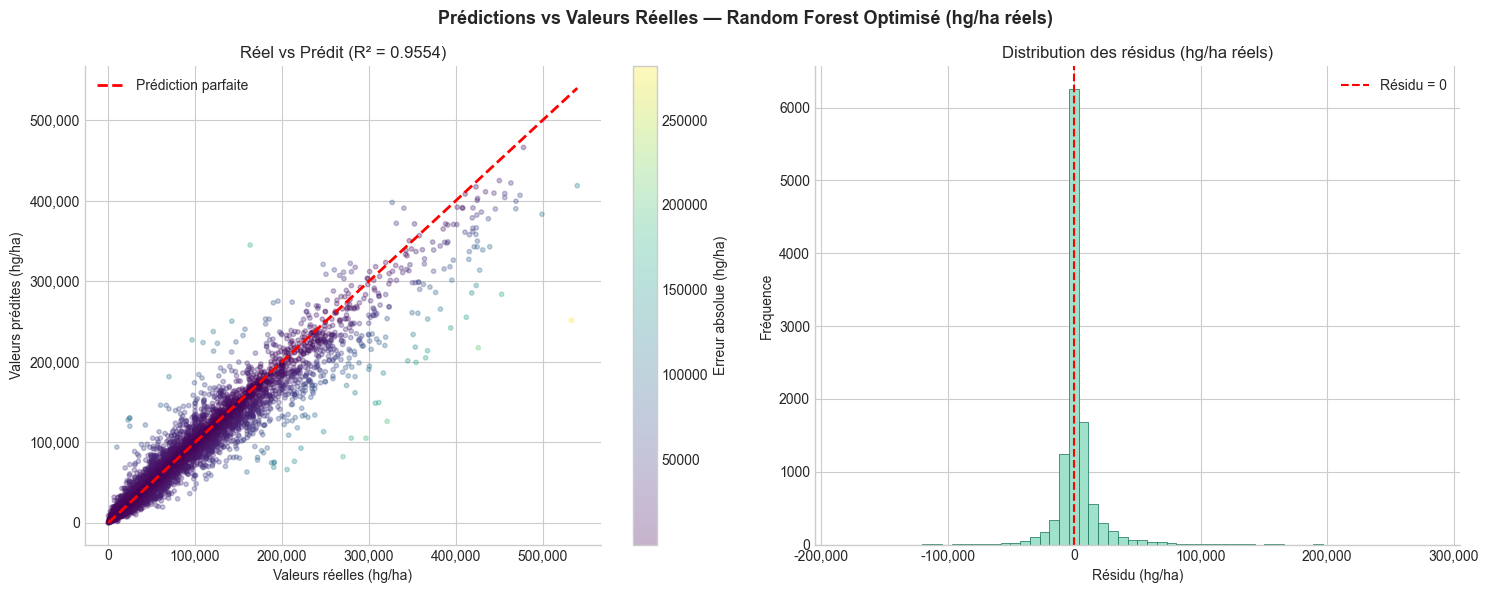

→ MAE en hg/ha réels    : 8,265 hg/ha
→ Erreur médiane (hg/ha): 3,223 hg/ha
→ MAPE                  : 16.20%


In [34]:
import matplotlib.pyplot as plt
import numpy as np

# CORRECTION 3 — Reconversion en hg/ha réels via expm1()
y_real_hgha = np.expm1(y_test)
y_pred_hgha = np.expm1(pred_test_best)
r2_test     = test_metrics["R²"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Prédictions vs Valeurs Réelles — Random Forest Optimisé (hg/ha réels)',
             fontsize=13, fontweight='bold')

# ── Scatter réel vs prédit ────────────────────────────────────────────
sc = axes[0].scatter(
    y_real_hgha, y_pred_hgha,
    alpha=0.3, s=10,
    c=np.abs(y_real_hgha - y_pred_hgha),
    cmap='viridis'
)
mn, mx = y_real_hgha.min(), y_real_hgha.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles (hg/ha)')
axes[0].set_ylabel('Valeurs prédites (hg/ha)')
axes[0].set_title(f'Réel vs Prédit (R² = {r2_test:.4f})')
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.colorbar(sc, ax=axes[0], label='Erreur absolue (hg/ha)')
axes[0].spines[['top','right']].set_visible(False)

# ── Distribution des résidus en hg/ha ────────────────────────────────
residuals_hgha = y_real_hgha - y_pred_hgha
axes[1].hist(residuals_hgha, bins=60, color='#9FE1CB', edgecolor='#0F6E56', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Résidu = 0')
axes[1].set_title('Distribution des résidus (hg/ha réels)')
axes[1].set_xlabel('Résidu (hg/ha)')
axes[1].set_ylabel('Fréquence')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f"→ MAE en hg/ha réels    : {np.mean(np.abs(residuals_hgha)):,.0f} hg/ha")
print(f"→ Erreur médiane (hg/ha): {np.median(np.abs(residuals_hgha)):,.0f} hg/ha")
print(f"→ MAPE                  : {test_metrics['MAPE (%)']:.2f}%")


### 14.2 Importance des Features

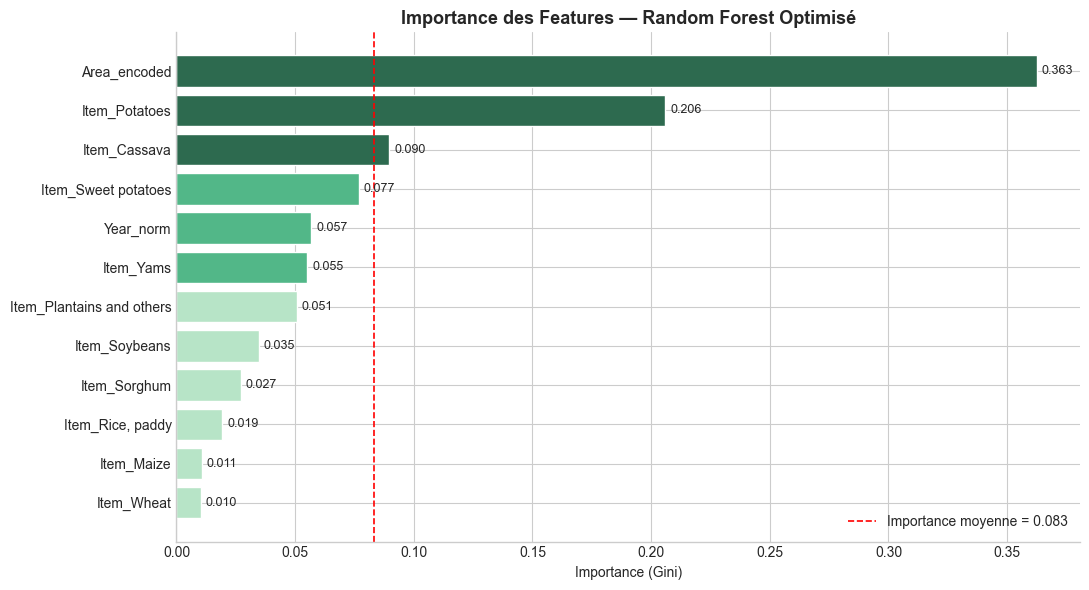


→ Features les plus importantes :
   Area_encoded              : 0.3626
   Item_Potatoes             : 0.2060
   Item_Cassava              : 0.0897
   Item_Sweet potatoes       : 0.0767
   Year_norm                 : 0.0568


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Feature importance du Random Forest optimisé ──────────────────────
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))

colors_fi = ['#2D6A4F' if v > feat_imp.quantile(0.75)
             else '#52B788' if v > feat_imp.quantile(0.50)
             else '#B7E4C7'
             for v in feat_imp.values]

bars = ax.barh(feat_imp.index, feat_imp.values,
               color=colors_fi, edgecolor='white')

for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.axvline(x=feat_imp.mean(), color='red', linestyle='--', linewidth=1.2,
           label=f'Importance moyenne = {feat_imp.mean():.3f}')

ax.set_title('Importance des Features — Random Forest Optimisé',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (Gini)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("\n→ Features les plus importantes :")
for feat, val in feat_imp.sort_values(ascending=False).head(5).items():
    print(f"   {feat:25s} : {val:.4f}")


### 14.3 Analyse des Résidus (Erreurs)

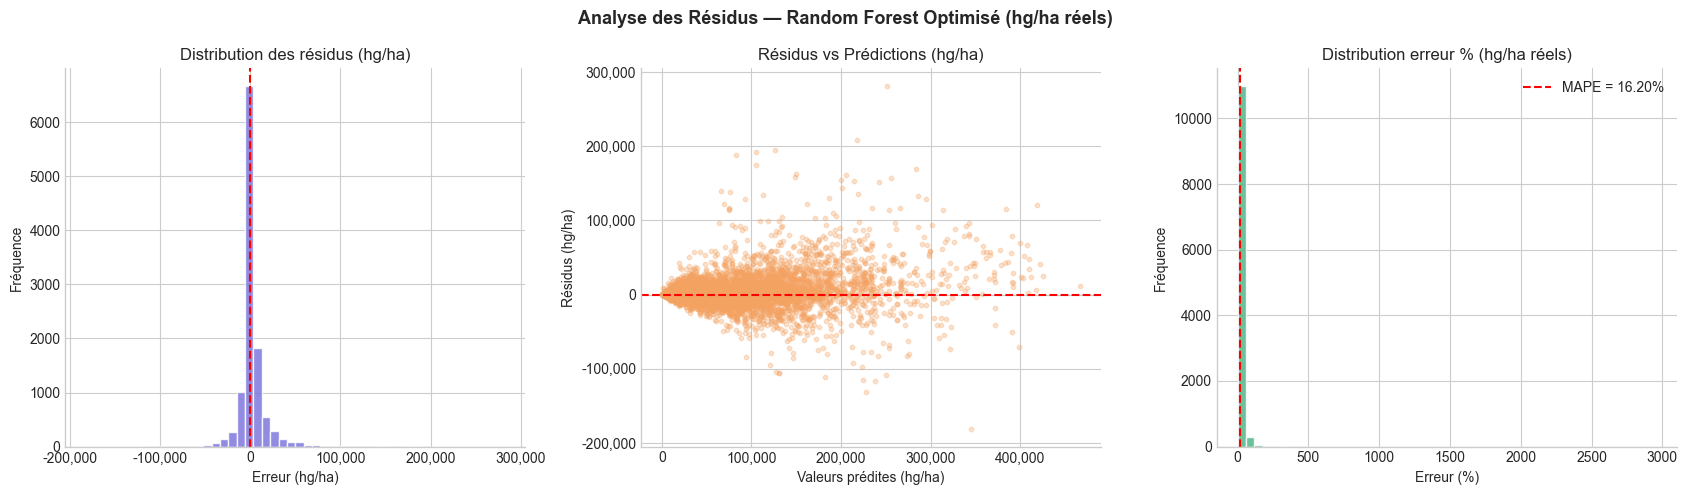

→ MAPE réel (hg/ha)  : 16.20%
→ Médiane erreur %   : 9.74%
→ % prédictions < 10%: 50.8% des cas
→ % prédictions < 20%: 75.2% des cas


In [36]:
import numpy as np
import matplotlib.pyplot as plt

# CORRECTION 3 — Résidus en hg/ha réels (via expm1)
y_real_hgha = np.expm1(y_test)
y_pred_hgha = np.expm1(pred_test_best)

residuals     = y_real_hgha - y_pred_hgha
residuals_pct = (residuals / (y_real_hgha + 1e-8)) * 100

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Analyse des Résidus — Random Forest Optimisé (hg/ha réels)',
             fontsize=13, fontweight='bold')

# ── 1. Distribution des résidus ───────────────────────────────────────
axes[0].hist(residuals, bins=50, color='#7F77DD', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribution des résidus (hg/ha)')
axes[0].set_xlabel('Erreur (hg/ha)')
axes[0].set_ylabel('Fréquence')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines[['top','right']].set_visible(False)

# ── 2. Résidus vs prédictions ─────────────────────────────────────────
axes[1].scatter(y_pred_hgha, residuals, alpha=0.3, s=10, color='#F4A261')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Résidus vs Prédictions (hg/ha)')
axes[1].set_xlabel('Valeurs prédites (hg/ha)')
axes[1].set_ylabel('Résidus (hg/ha)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].spines[['top','right']].set_visible(False)

# ── 3. Distribution erreur % ──────────────────────────────────────────
abs_pct = np.abs(residuals_pct)
axes[2].hist(abs_pct, bins=50, color='#52B788', edgecolor='white', alpha=0.85)
axes[2].axvline(np.mean(abs_pct), color='red', linestyle='--',
                label=f'MAPE = {np.mean(abs_pct):.2f}%')
axes[2].set_title('Distribution erreur % (hg/ha réels)')
axes[2].set_xlabel('Erreur (%)')
axes[2].set_ylabel('Fréquence')
axes[2].legend()
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f"→ MAPE réel (hg/ha)  : {np.mean(abs_pct):.2f}%")
print(f"→ Médiane erreur %   : {np.median(abs_pct):.2f}%")
print(f"→ % prédictions < 10%: {(abs_pct < 10).mean()*100:.1f}% des cas")
print(f"→ % prédictions < 20%: {(abs_pct < 20).mean()*100:.1f}% des cas")


##  Partie 15 — Sauvegarde des Artefacts

In [37]:
import joblib
import json
import os
import numpy as np

print('💾 Sauvegarde des artefacts...')

# ── 1. Modèle Random Forest optimisé ──────────────────────────────────
joblib.dump(best_model, f'{ARTIFACTS_DIR}/reg_best_model.pkl')
print('   ✓ reg_best_model.pkl')

# ── 2. Scaler ─────────────────────────────────────────────────────────
joblib.dump(scaler, f'{ARTIFACTS_DIR}/reg_scaler.pkl')
print('   ✓ reg_scaler.pkl')

# ── 3. One-Hot Encoder (Item) ─────────────────────────────────────────
joblib.dump(ohe, f'{ARTIFACTS_DIR}/reg_ohe_item.pkl')
print('   ✓ reg_ohe_item.pkl')

# ── 4. Feature columns ────────────────────────────────────────────────
joblib.dump(feature_cols, f'{ARTIFACTS_DIR}/reg_feature_columns.pkl')
print('   ✓ reg_feature_columns.pkl')

# ── 5. Target Encoding map (area_means) ───────────────────────────────
# IMPORTANT : sauvegarder area_means pour l'inférence future
joblib.dump(area_means, f'{ARTIFACTS_DIR}/reg_area_means.pkl')
print('   ✓ reg_area_means.pkl')

# ── 6. Hyperparamètres optimaux ───────────────────────────────────────
best_params_serializable = {
    k: (int(v)   if isinstance(v, (int,))
        else float(v) if isinstance(v, (float,))
        else str(v)   if v is not None
        else None)
    for k, v in best_params.items()
}

with open(f'{ARTIFACTS_DIR}/reg_best_hyperparams.json', 'w') as f:
    json.dump(best_params_serializable, f, indent=2)
print('   ✓ reg_best_hyperparams.json')

# ── 7. Métriques de performance ───────────────────────────────────────
perf = {
    'model': 'RandomForestRegressor (Optimized)',
    'train': train_metrics,
    'test':  test_metrics,
    'cv_r2_mean': float(cv_scores.mean()),
    'cv_r2_std':  float(cv_scores.std()),
    'overfitting_gap': float(train_metrics["R²"] - test_metrics["R²"])
}

with open(f'{ARTIFACTS_DIR}/reg_performance.json', 'w') as f:
    json.dump(perf, f, indent=2)
print('   ✓ reg_performance.json')

# ── Summary ────────────────────────────────────────────────────────────
print('\n' + '═'*50)
print('   ✅ Tous les artefacts sauvegardés avec succès !')
print(f'   Dossier : {os.path.abspath(ARTIFACTS_DIR)}')
print('═'*50)

print('\nFichiers créés :')
for fname in sorted(os.listdir(ARTIFACTS_DIR)):
    fpath = f'{ARTIFACTS_DIR}/{fname}'
    size  = os.path.getsize(fpath)
    print(f'   {fname:40s}  {size/1024:.1f} KB')


💾 Sauvegarde des artefacts...
   ✓ reg_best_model.pkl
   ✓ reg_scaler.pkl
   ✓ reg_ohe_item.pkl
   ✓ reg_feature_columns.pkl
   ✓ reg_area_means.pkl
   ✓ reg_best_hyperparams.json
   ✓ reg_performance.json

══════════════════════════════════════════════════
   ✅ Tous les artefacts sauvegardés avec succès !
   Dossier : c:\Users\sofya\Downloads\projet_ML\artifacts
══════════════════════════════════════════════════

Fichiers créés :
   cls_best_model.pkl                        6277.0 KB
   cls_feature_columns.pkl                   0.1 KB
   cls_label_encoder.pkl                     0.7 KB
   cls_scaler.pkl                            1.2 KB
   reg_area_means.pkl                        10.0 KB
   reg_best_hyperparams.json                 0.1 KB
   reg_best_model.pkl                        635363.5 KB
   reg_feature_columns.pkl                   0.2 KB
   reg_ohe_item.pkl                          1.1 KB
   reg_performance.json                      0.4 KB
   reg_scaler.pkl                   

In [38]:
import os
from datetime import datetime

print("📁 Vérification des artefacts de régression :")
files_reg = [
    "reg_best_model.pkl",
    "reg_scaler.pkl",
    "reg_ohe_item.pkl",
    "reg_feature_columns.pkl",
    "reg_area_means.pkl",
    "reg_best_hyperparams.json",
    "reg_performance.json",
]

for f in files_reg:
    path = os.path.join(ARTIFACTS_DIR, f)
    if os.path.exists(path):
        modif = datetime.fromtimestamp(os.path.getmtime(path))
        size  = os.path.getsize(path)
        print(f"   ✅ {f:40s} {size/1024:6.1f} KB  —  {modif:%Y-%m-%d %H:%M:%S}")
    else:
        print(f"   ❌ {f:40s} → Fichier introuvable")


📁 Vérification des artefacts de régression :
   ✅ reg_best_model.pkl                       635363.5 KB  —  2026-06-10 22:17:03
   ✅ reg_scaler.pkl                              1.1 KB  —  2026-06-10 22:17:03
   ✅ reg_ohe_item.pkl                            1.1 KB  —  2026-06-10 22:17:03
   ✅ reg_feature_columns.pkl                     0.2 KB  —  2026-06-10 22:17:03
   ✅ reg_area_means.pkl                         10.0 KB  —  2026-06-10 22:17:03
   ✅ reg_best_hyperparams.json                   0.1 KB  —  2026-06-10 22:17:03
   ✅ reg_performance.json                        0.4 KB  —  2026-06-10 22:17:03


In [81]:
import os
from datetime import datetime

print("📁 Contenu complet du dossier artifacts :")
for f in sorted(os.listdir(ARTIFACTS_DIR)):
    path  = os.path.join(ARTIFACTS_DIR, f)
    modif = datetime.fromtimestamp(os.path.getmtime(path))
    size  = os.path.getsize(path)
    print(f"   {f:40s} {size/1024:6.1f} KB  —  {modif:%H:%M:%S}")


baseline_comparison.png             2026-06-03 12:24:47.786721
feature_importance.png              2026-06-03 12:35:10.275163
overfitting_analysis.png            2026-06-03 12:34:22.388008
predictions_vs_real.png             2026-06-03 12:34:44.905446
reg_best_hyperparams.json           2026-06-03 17:57:25.480133
reg_best_model.pkl                  2026-06-03 17:57:25.469134
reg_feature_columns.pkl             2026-06-03 17:57:25.478133
reg_ohe_item.pkl                    2026-06-03 17:57:25.476130
reg_performance.json                2026-06-03 17:57:25.484230
reg_scaler.pkl                      2026-06-03 17:57:25.473134
residuals_analysis.png              2026-06-03 12:39:10.182780
